In [12]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [13]:
# ============================================================
# CREDIT SCORING MODEL
# VertexMind Internship - Task 1
# ============================================================

# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [14]:
# Generate synthetic dataset

X, y = make_classification(
    n_samples=5000,
    n_features=6,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    weights=[0.85, 0.15],
    random_state=42
)

# Feature names

columns = [
    'income',
    'age',
    'debt_ratio',
    'number_of_loans',
    'payment_history',
    'credit_lines_open'
]

# Create dataframe

df = pd.DataFrame(X, columns=columns)

# Add target column

df['target'] = y

# Add missing values artificially

for col in columns:
    df.loc[df.sample(frac=0.02, random_state=42).index, col] = np.nan

print("Dataset Created Successfully")

# Display first 5 rows

df.head()

Dataset Created Successfully


,income,age,debt_ratio,number_of_loans,payment_history,credit_lines_open,target
0,0.425673,0.800202,-0.074264,0.063835,1.563656,1.472417,1
1,-0.015882,0.523859,0.301699,-0.720960,-1.148072,-3.373593,0
2,1.829393,1.089778,3.075901,-0.278184,-2.946205,2.487613,0
3,0.820890,-0.458231,1.153644,1.805981,-1.968799,-0.809510,0
4,3.444117,0.574779,4.197319,3.523733,-3.950783,3.303338,0


In [5]:
# Dataset Information

print("Dataset Shape:")
print(df.shape)

print("\n================================")

print("Missing Values:")
print(df.isnull().sum())

print("\n================================")

print("Target Distribution:")
print(df['target'].value_counts())

Dataset Shape:
(5000, 7)

Missing Values:
income               100
age                  100
debt_ratio           100
number_of_loans      100
payment_history      100
credit_lines_open    100
target                 0
dtype: int64

Target Distribution:
target
0    4239
1     761
Name: count, dtype: int64


In [6]:
# Separate features and target

X = df.drop('target', axis=1)
y = df['target']

# Handle missing values using mean strategy

imputer = SimpleImputer(strategy='mean')

X = imputer.fit_transform(X)

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [7]:
# Split dataset into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

Training Data Shape:
(4000, 6)

Testing Data Shape:
(1000, 6)


In [8]:
# Apply SMOTE to balance the dataset

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\n================================")

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
target
0    3391
1     609
Name: count, dtype: int64

After SMOTE:
target
0    3391
1    3391
Name: count, dtype: int64


In [9]:
# Feature Scaling

scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train_smote)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully



Logistic Regression
Accuracy  : 0.7920
Precision : 0.4067
Recall    : 0.8026
F1 Score  : 0.5398
ROC AUC   : 0.8551

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.79      0.87       848
           1       0.41      0.80      0.54       152

    accuracy                           0.79      1000
   macro avg       0.68      0.80      0.70      1000
weighted avg       0.87      0.79      0.82      1000



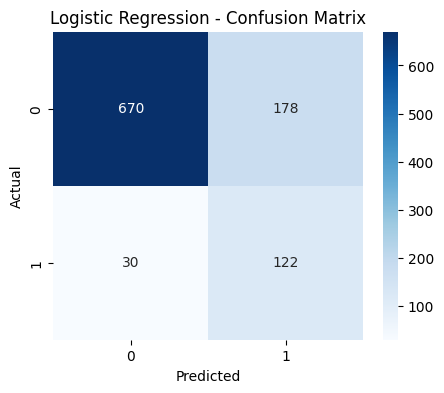

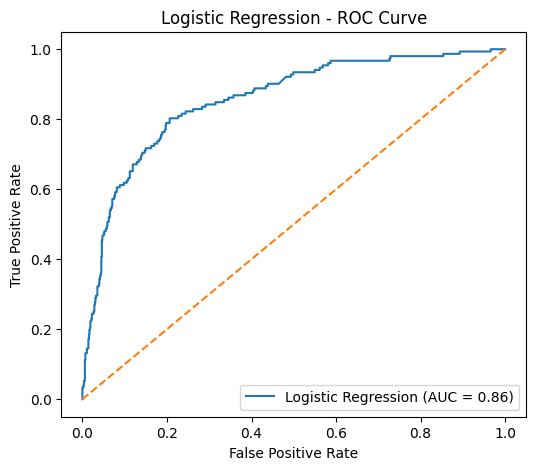


Decision Tree
Accuracy  : 0.9030
Precision : 0.6590
Recall    : 0.7500
F1 Score  : 0.7015
ROC AUC   : 0.8473

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       848
           1       0.66      0.75      0.70       152

    accuracy                           0.90      1000
   macro avg       0.81      0.84      0.82      1000
weighted avg       0.91      0.90      0.91      1000



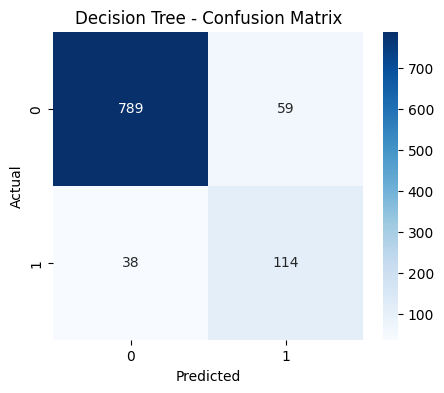

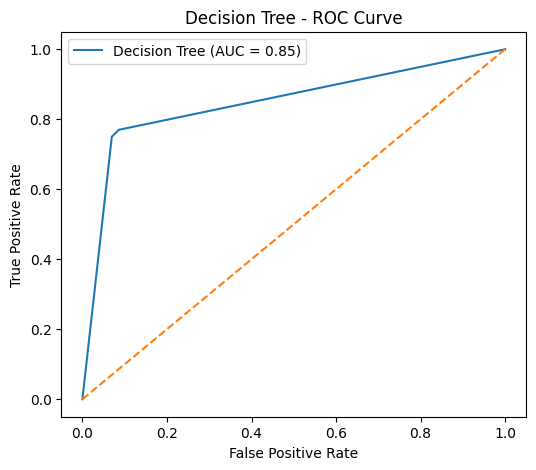


Random Forest
Accuracy  : 0.9310
Precision : 0.7610
Recall    : 0.7961
F1 Score  : 0.7781
ROC AUC   : 0.9600

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       848
           1       0.76      0.80      0.78       152

    accuracy                           0.93      1000
   macro avg       0.86      0.88      0.87      1000
weighted avg       0.93      0.93      0.93      1000



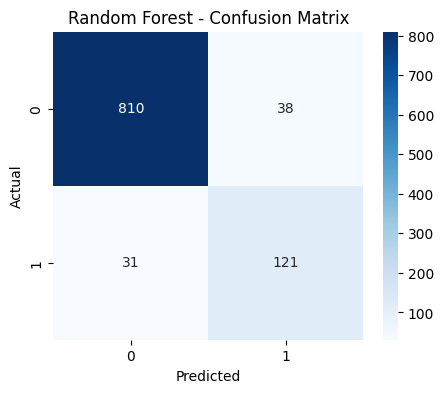

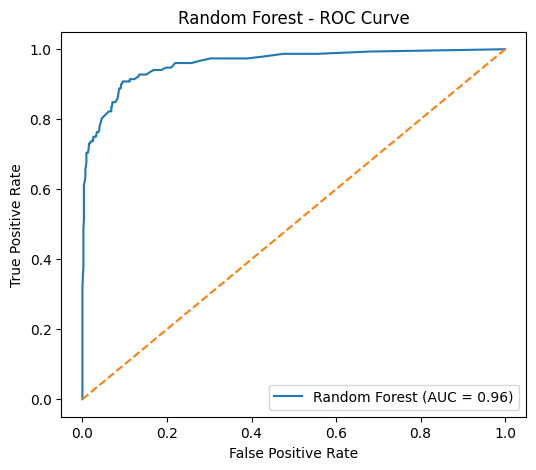

In [10]:
# ============================================================
# TRAIN MACHINE LEARNING MODELS
# ============================================================

# Initialize models

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Store results
results = {}

# Train and evaluate each model

for name, model in models.items():

    print("\n================================================")
    print(name)
    print("================================================")

    # Train model
    model.fit(X_train_scaled, y_train_smote)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability predictions
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Save ROC AUC
    results[name] = roc_auc

    # Print metrics
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ============================================================
    # CONFUSION MATRIX
    # ============================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'{name} - Confusion Matrix')

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

    # ============================================================
    # ROC CURVE
    # ============================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.2f})'
    )

    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel('False Positive Rate')

    plt.ylabel('True Positive Rate')

    plt.title(f'{name} - ROC Curve')

    plt.legend()

    plt.show()

In [11]:
# ============================================================
# BEST PERFORMING MODEL
# ============================================================

best_model = max(results, key=results.get)

print("================================")
print("Best Performing Model")
print("================================")

print(f"\nModel Name: {best_model}")

print(f"\nROC AUC Score: {results[best_model]:.4f}")

Best Performing Model

Model Name: Random Forest

ROC AUC Score: 0.9600


In [17]:
# ============================================================
# USER INPUT CREDIT SCORING PREDICTION
# ============================================================

# Train Random Forest model

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train_smote)

print("========================================")
print(" CREDIT SCORING PREDICTION SYSTEM ")
print("========================================")

# User Input

income = float(input("Enter Income: "))
age = float(input("Enter Age: "))
debt_ratio = float(input("Enter Debt Ratio (0 to 1): "))
number_of_loans = float(input("Enter Number of Loans: "))
payment_history = float(input("Enter Payment History Score (0 or 1): "))
credit_lines_open = float(input("Enter Credit Lines Open: "))

# Create user data array

user_data = np.array([[
    income,
    age,
    debt_ratio,
    number_of_loans,
    payment_history,
    credit_lines_open
]])

# Scale the input

user_data_scaled = scaler.transform(user_data)

# Prediction

prediction = rf_model.predict(user_data_scaled)

# Probability score

probability = rf_model.predict_proba(user_data_scaled)[0][1]

# ============================================================
# FINAL RESULT
# ============================================================

print("\n========================================")
print(" CREDIT SCORING RESULT ")
print("========================================")

if prediction[0] == 1:

    print("\nPrediction : HIGH CREDIT RISK")

    print(f"Risk Probability : {probability:.2f}")

    print("\nLoan Approval Status : NOT RECOMMENDED")

else:

    print("\nPrediction : LOW CREDIT RISK")

    print(f"Risk Probability : {probability:.2f}")

    print("\nLoan Approval Status : RECOMMENDED")

print("\n========================================")

    # ============================================================
# SAMPLE INPUT VALUES
# ============================================================

# GOOD CREDIT CUSTOMER EXAMPLE
#
# Income: 90000
# Age: 35
# Debt Ratio: 0.2
# Number of Loans: 1
# Payment History Score: 1
# Credit Lines Open: 6
#
# Expected Output:
# LOW CREDIT RISK
# Loan Approval Status : RECOMMENDED


# BAD CREDIT CUSTOMER EXAMPLE
#
# Income: 10000
# Age: 20
# Debt Ratio: 0.9
# Number of Loans: 8
# Payment History Score: 0
# Credit Lines Open: 1
#
# Expected Output:
# HIGH CREDIT RISK
# Loan Approval Status : NOT RECOMMENDED

 CREDIT SCORING PREDICTION SYSTEM 

 CREDIT SCORING RESULT 

Prediction : LOW CREDIT RISK
Risk Probability : 0.50

Loan Approval Status : RECOMMENDED

